# Solving the 2D Helmholtz Equation Using Physics Informed Neural Network 

Solve the following nonlinear PDE:

$$ u_{xx} + u_{yy} + k^{2} u - q(x,y)  = 0, \quad (x,y) \in (-1,1) \times (-1,1) $$
$$ u(-1,y) = u(1,y) = u(x,-1) = u(x,1) = 0, $$
$$ q(x,y) = (k^{2} - (a_{1}\pi)^{2} - (a_{2} \pi)^{2}) \sin(a_{1} \pi x) \sin(a_{2} \pi y) $$
$$ u(x,y) = \sin(a_{1}\pi x) \sin(a_{2}\pi y) $$ 


In [6]:
import torch 
from torch import nn
import math 
import numpy as np 
import matplotlib.pyplot as plt 
from Helmholtz_utils import * 
from utils.PINN_structure import * 
from mpl_toolkits.axes_grid1 import make_axes_locatable # allows you to easily add new axes next to an existing plot 
import warnings


# warnings.filterwarnings('ignore') 

import time 

# np.random.seed(1234) 

In [7]:
# MPS or CUDA or CPU 
if torch.backends.mps.is_available(): 
    device = torch.device('mps') 
elif torch.cuda.is_available(): 
    device = torch.device('cuda') 
else: 
    devcie = torch.device('cpu') 

print(f"Wroking on {device}") 

Wroking on mps


<span style="font-size:20pt"> Building the PINN </span>

In [6]:
# The deep neural network 
class DNN(nn.Module):
    def __init__(self, layers): 
        super(DNN, self).__init__() 

        # parameters 
        self.depth = len(layers) - 1 

        # set up layer order dict 
        self.activation = nn.Tanh 

        layer_list = list() 
        for i in range(self.depth - 1): 
            layer_list.append(
                ('layer_%d' % i, nn.Linear(layers[i], layers[i+1])) 
            ) 
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), nn.Linear(layers[-2], layers[-1]))
        ) 
        layerDict = OrderedDict(layer_list)
        
        # deploy layers 
        self.layers = nn.Sequential(layerDict) 

    def forward(self, x): 
        out = self.layers(x) 

        return out 

    
        

In [16]:
class PINN_Helmholtz():
    def __init__(self, X_train, X_bc, lb, ub, layers, k = 1, a1 = 1, a2 = 4):  
        # Parameter Setting
        self.k = k 
        self.a1 = a1 
        self.a2 = a2 
        
        # boundary conditions: domain bounds 
        self.lb = torch.as_tensor(lb).float().to(device) 
        self.ub = torch.as_tensor(ub).float().to(device) 
        

        # Training data 
        self.X_train = torch.as_tensor(X_train, dtype = torch.float32).to(device) 
        self.X_train.requires_grad_(True) 
        self.x = self.X_train[:, 0:1] # x-axis 
        self.y = self.X_train[:, 1:2] # y-axis 
        self.N_int = self.X_train.shape[0]
        
        # Boundary data 
        self.BC_left = torch.tensor(X_bc[:,0:2]).float().to(device) 
        self.BC_right = torch.tensor(X_bc[:,2:4]).float().to(device) 
        self.BC_down = torch.tensor(X_bc[:, 4:6]).float().to(device) 
        self.BC_up = torch.tensor(X_bc[:, 6:8]).float().to(device) 
        self.N_bc = self.BC_left.shape[0]
        
        # No need to learn any parameters in this semilinear equations 
        # deep neural networks     
        self.dnn = DNN(layers).to(device) 

        # Iteration parameter 
        self.iter = 0 

        # First Order Optimizer : Adam
        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters(), lr = 2e-4, betas = (0.9, 0.999)) # or take weight decay = 2.0
        
        # Second Order optimizer: LBFGS 
        self.optimizer = torch.optim.LBFGS( # require multiple evaluations of the loss function per iteraton
            self.dnn.parameters(), # target to be optimized 
            lr = 1.0, # learning rate: step length 
            max_iter = 1, # maximum number of iterations: can be reduced 
            max_eval = 50000, # total numebr of times the closure ( loss + backward pass) can be called
            history_size = 50, 
            tolerance_grad = 0, 
            tolerance_change = 0,
            line_search_fn = "strong_wolfe" 
        ) 
        
    def q(self, X): 
        a1 = self.a1 * torch.pi 
        a2 = self.a2 * torch.pi 
        return (self.k ** 2 - a1 ** 2 - a2 ** 2) * torch.sin(a1 * X[:, 0:1]) * torch.sin(a2 * X[:, 1:2])    
    
    def net_u(self, X): # predicted value 
        u = self.dnn(X)
        return u 

    def PDE_residual(self, X): 
        u = self.net_u(X) 
        q = self.q(X) 
        
        grad_u = torch.autograd.grad(
            outputs = u, 
            inputs = X, 
            grad_outputs = torch.ones_like(u),
            create_graph = True
        )[0] # shape (N, 2) 

        u_x = grad_u[:, 0:1] 
        u_y = grad_u[:, 1:2]  
        
        u_xx = torch.autograd.grad(
            u_x, X, 
            grad_outputs = torch.ones_like(u_x), 
            create_graph = True
        )[0][:, 0:1]

        u_yy = torch.autograd.grad(
            u_y, X, 
            grad_outputs = torch.ones_like(u_y),
            create_graph = True 
        )[0][:, 1:2]
            
        # PDE residual loss 
        f = u_xx + u_yy + (self.k ** 2) * u - q    
        return f 
        
    # Boundary condition loss 
    def Bc_loss_func(self):
        u_left = self.net_u(self.BC_left) 
        u_right = self.net_u(self.BC_right) 
        u_down = self.net_u(self.BC_down) 
        u_up = self.net_u(self.BC_up) 
        bc_loss = (torch.mean(torch.pow(u_left,2)) + torch.mean(torch.pow(u_right,2)) + torch.mean(torch.pow(u_down, 2)) + torch.mean(torch.pow(u_up, 2))) 
        return bc_loss 

    # Optimization step
    def loss_func(self): 
        f_pred = self.PDE_residual(self.X_train)  
        loss = torch.mean(torch.pow(f_pred, 2)) + self.Bc_loss_func()

        return loss 
    
    def closure(self): 
        loss_value = self.loss_func() 
        self.optimizer.zero_grad()    # reset gradients
        loss_value.backward()         # compute gradients but only the network weights will be updated 
        return loss_value  

        
    def Optimize(self, nIter_1, nIter_2 = 2000): 
        self.dnn.train() 
        # Two Phase Optimization
        # Step 1: Adam: gradient descent method 
        for epoch in range(nIter_1):
            # total loss 
            loss = self.loss_func() 
            
            # Backward and optimize 
            # Network parameter update 
            self.optimizer_Adam.zero_grad()
            
            # self.optimizer_Muon.zero_grad()
            loss.backward()
            self.optimizer_Adam.step() # only sees the gradient of the network weights 
            
            if epoch % 100 == 0: 
                print(
                    'It: %d, Loss: %.3e' % 
                    ( 
                        epoch, 
                        loss.item(),   
                    )
                )
        # Second Phase Optimization         
        for i in range(nIter_2):
            loss_value = self.optimizer.step(self.closure) # Never pass tensors into optimizer.step
            self.iter += 1
            if self.iter % 100 == 0:
                print('It: %d, Loss: %e' % (self.iter, loss_value.item()))
            

                
    def predict(self, X, X_bc = None): 
        X_test = torch.tensor(X, requires_grad = True).float().to(device) 
        self.dnn.eval()  
        with torch.no_grad():
            u = self.net_u(X_test)
        f = self.PDE_residual(X_test) 
        u = u.detach().cpu().numpy() 
        f = f.detach().cpu().numpy() 
        return u, f

# Configurations 

In [17]:
# Domain bounds 
lb = np.array([-1.0, -1.0]) 
ub = np.array([1.0, 1.0]) 
k = 1
a1 = 1 
a2 = 4                                                   

# Grid point setup 
N_bc = 100
N_x = 40
N_y = 120 


# Training points 
X_train_int = interior_points(N_x, N_y, lb[0], ub[0], lb[1], ub[1]) 
print(f"X_train_int shape: {np.shape(X_train_int)}")
X_train_bc = bc_points(N_bc, lb[0], ub[0], lb[1], ub[1])
print(f"X_train_bc shape: {np.shape(X_train_bc)}") 



X_train_int shape: (4800, 2)
X_train_bc shape: (100, 8)


# Generate Test data and solution  

In [18]:
# Generate test data 
N = 100
X_test, u_test = test_data(N) 

print(f"X_test shape: {X_test.shape}") 
print(f"u_test shape: {u_test.shape}") 

X_test shape: (10000, 2)
u_test shape: (10000, 1)


# Training on Non-noisy Data 

In [19]:
# torch.manual_seed(42) 
noise = 0.0 
layers = [2, 50, 50, 50, 50, 1] 


# training 
model = PINN_Helmholtz(X_train_int, X_train_bc, lb, ub, layers) 
start = time.time() 
model.Optimize(5000, 5000) 

end = time.time() 

It: 0, Loss: 5.603e+03
It: 100, Loss: 5.587e+03
It: 200, Loss: 5.023e+03
It: 300, Loss: 4.540e+03
It: 400, Loss: 4.098e+03
It: 500, Loss: 3.870e+03
It: 600, Loss: 3.706e+03
It: 700, Loss: 3.536e+03
It: 800, Loss: 3.105e+03
It: 900, Loss: 2.903e+03
It: 1000, Loss: 2.830e+03
It: 1100, Loss: 2.776e+03
It: 1200, Loss: 2.726e+03
It: 1300, Loss: 2.674e+03
It: 1400, Loss: 2.574e+03
It: 1500, Loss: 2.469e+03
It: 1600, Loss: 2.437e+03
It: 1700, Loss: 2.424e+03
It: 1800, Loss: 2.414e+03
It: 1900, Loss: 2.388e+03
It: 2000, Loss: 1.858e+03
It: 2100, Loss: 1.483e+03
It: 2200, Loss: 1.302e+03
It: 2300, Loss: 1.229e+03
It: 2400, Loss: 1.204e+03
It: 2500, Loss: 1.179e+03
It: 2600, Loss: 6.644e+02
It: 2700, Loss: 2.089e+02
It: 2800, Loss: 1.097e+02
It: 2900, Loss: 4.444e+01
It: 3000, Loss: 2.209e+01
It: 3100, Loss: 1.446e+01
It: 3200, Loss: 1.040e+01
It: 3300, Loss: 7.888e+00
It: 3400, Loss: 6.203e+00
It: 3500, Loss: 4.991e+00
It: 3600, Loss: 4.159e+00
It: 3700, Loss: 3.500e+00
It: 3800, Loss: 3.032e+0

# Test the accuracy of the learned solution 

In [20]:
# evaluations 
u_pred, f_pred = model.predict(X_test)  

print(f"u_pred shape: {np.shape(u_pred)}") 
# print(f"f_pred shape: {np.shape(f_pred)}")  
print(f"u_test shape: {np.shape(u_test)}") 

error_u = np.linalg.norm(abs(u_test - u_pred), 2) / np.linalg.norm(u_test, 2) # relative L^{2} square norm 
# error_f = np.linalg.norm(abs(f_pred), ord = np.inf) 


print('Error u: %e' % (error_u)) 
# print('PDE loss: %e' % (error_f)) 
print(f'Training time is {end - start:.2f} seconds')



u_pred shape: (10000, 1)
u_test shape: (10000, 1)
Error u: 7.251908e-03
Training time is 310.96 seconds


# Collect Error Data 

In [31]:
# torch.manual_seed(42)
noise = 0.0 
err_l2 = np.zeros([10]) 
err_linf = np.zeros([10]) 
Training_time = np.zeros([10]) 
k = 1 
a1 = 1
a2 = 4
# Training points 
training_sets = np.load(
    "Helmholtz_2d_training_points_4800_sets.npy",
    allow_pickle=True
)
layers = [2, 50, 50, 50, 50, 1]

for k in range(10): 
    data = training_sets[k] 
    X_train_int = data["X_train_int"] 
    X_train_bc = data["X_train_bc"] 
    model = PINN_Helmholtz(X_train_int, X_train_bc, lb, ub, layers) 
    start = time.time() 
    model.Optimize(5000, 5000) 
    end = time.time() 
    u_pred = model.predict(X_test) 
    err_l2[k] = np.linalg.norm(abs(u_test - u_pred), 2) / np.linalg.norm(u_test, 2) 
    err_linf[k] = np.max(np.abs(u_test - u_pred))
    Training_time[k] = (end - start) 

It: 0, Loss: 7.062e+03
It: 100, Loss: 7.044e+03
It: 200, Loss: 6.899e+03
It: 300, Loss: 6.143e+03
It: 400, Loss: 5.698e+03
It: 500, Loss: 4.579e+03
It: 600, Loss: 2.875e+03
It: 700, Loss: 2.463e+03
It: 800, Loss: 1.966e+03
It: 900, Loss: 1.603e+03
It: 1000, Loss: 1.381e+03
It: 1100, Loss: 1.077e+03
It: 1200, Loss: 8.510e+02
It: 1300, Loss: 6.878e+02
It: 1400, Loss: 5.303e+02
It: 1500, Loss: 4.386e+02
It: 1600, Loss: 3.755e+02
It: 1700, Loss: 2.978e+02
It: 1800, Loss: 2.423e+02
It: 1900, Loss: 2.029e+02
It: 2000, Loss: 1.732e+02
It: 2100, Loss: 1.461e+02
It: 2200, Loss: 1.206e+02
It: 2300, Loss: 1.007e+02
It: 2400, Loss: 8.543e+01
It: 2500, Loss: 7.297e+01
It: 2600, Loss: 6.231e+01
It: 2700, Loss: 5.368e+01
It: 2800, Loss: 4.626e+01
It: 2900, Loss: 3.955e+01
It: 3000, Loss: 3.355e+01
It: 3100, Loss: 2.866e+01
It: 3200, Loss: 2.500e+01
It: 3300, Loss: 2.219e+01
It: 3400, Loss: 1.994e+01
It: 3500, Loss: 1.807e+01
It: 3600, Loss: 1.651e+01
It: 3700, Loss: 1.519e+01
It: 3800, Loss: 1.408e+0

In [34]:
# Save the results 
results = {
    "Model": "PINN",
    "Layers": [2, 50, 50, 50, 50, 1], 
    "Training_points_int_bc": [N_x, N_y, N_bc], 
    "L2_error": err_l2,
    "Linf_error": err_linf,  
    "Training_time": Training_time,
}

# torch.save(results, "Helmholtz_PINN_4800_training_points_data.pt")

In [27]:
print("err_l2 mean: ", np.mean(err_l2))
print("err_linf mean: ", np.mean(err_linf)) 
print("err_l2 std: ", np.std(err_l2)) 
print("err_linf std: ", np.std(err_linf))

[0.00595145 1.62548965 4.29926363 0.00791419 0.01095986 1.86036724
 1.46124496 0.00543416 0.00866819 0.26265716]
0.9547950501361738
1.3294759579896396
1.8977639421134413
2.4359055198099306
371.4292631149292
141.15609509577942


# Visualization 

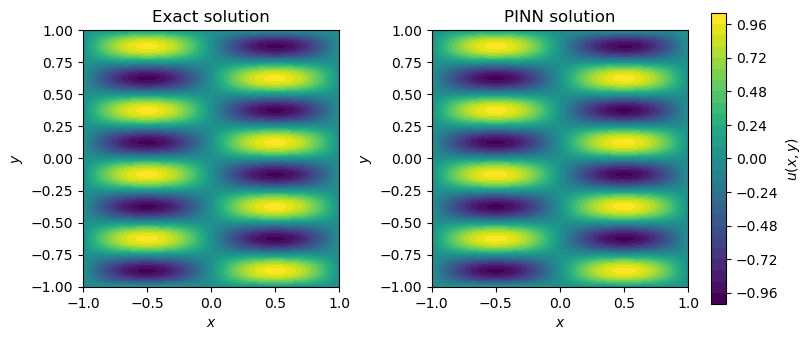

In [24]:
import matplotlib.gridspec as gridspec 


# Predicted solution
U_pred = u_pred.reshape(N, N)
U_true = u_test.reshape(N, N) 
XX = X_test[:, 0:1].reshape(N, N) 
YY = X_test[:, 1:2].reshape(N, N) 
# Use the same color scale for both plots
vmin = min(U_true.min(), U_pred.min())
vmax = max(U_true.max(), U_pred.max())

# Create figure
fig, axes = plt.subplots(
    1, 2,
    figsize=(8, 3.5),
    constrained_layout=True
)

# -----------------------------
# Exact solution
# -----------------------------
contour0 = axes[0].contourf(
    XX, YY, U_true,
    levels=30,
    vmin=vmin,
    vmax=vmax,
    cmap="viridis"
)

axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$y$")
axes[0].set_title("Exact solution")
axes[0].set_aspect("equal")

# -----------------------------
# Random feature solution
# -----------------------------
contour1 = axes[1].contourf(
    XX, YY, U_pred,
    levels=30,
    vmin=vmin,
    vmax=vmax,
    cmap="viridis"
)

axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"$y$")
axes[1].set_title("PINN solution")
axes[1].set_aspect("equal")

# -----------------------------
# Shared colorbar
# -----------------------------
cbar = fig.colorbar(
    contour1,
    ax=axes,
    shrink=0.9,
    pad=0.02
)
cbar.set_label(r"$u(x,y)$")

# -----------------------------
# Save figure
# -----------------------------
""" 
fig.savefig(
    "Helmholtz_solution_PINN.pdf",
    bbox_inches="tight"
)
""" 

plt.show()

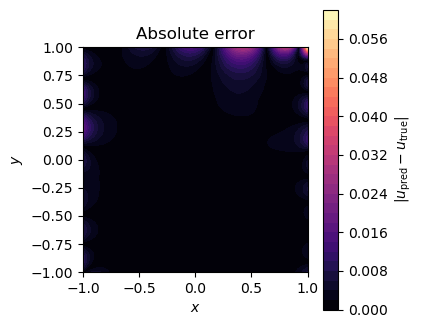

In [23]:
# Absolute error
error = np.abs(U_pred - U_true)

# Create figure
fig, ax = plt.subplots(
    1, 1,
    figsize=(4, 3.5),
    constrained_layout=True
)

# -----------------------------
# Absolute error
# -----------------------------
contour = ax.contourf(
    XX, YY, error,
    levels=30,
    cmap="magma"
)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title("Absolute error")
ax.set_aspect("equal")

# -----------------------------
# Colorbar
# -----------------------------
cbar = fig.colorbar(
    contour,
    ax=ax,
    shrink=0.9,
    pad=0.02
)
cbar.set_label(r"$|u_{\mathrm{pred}}-u_{\mathrm{true}}|$")

# -----------------------------
# Save figure
# -----------------------------
"""
fig.savefig(
    "Helmholtz_error_PINN.pdf",
    bbox_inches="tight"
)
"""

plt.show()